In [1]:
#Uncomment and run the following line to install the lifelines package
#!pip install lifelines

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from lifelines import datasets, CoxPHFitter, KaplanMeierFitter

# Assignment 1: Survival Analysis

## Setup

As is common in medical data, the dataset contains missing values. The following code performs some basic imputation to address this. More on imputation in Module 7!

In [3]:
# Load the lung dataset and perform median and mode imputation

lung_df = datasets.load_lung()

continous_columns = ["inst", "time", "age", "ph.karno", "pat.karno", "meal.cal", "wt.loss"] # 'inst' will be considered as a discrete variable
median_imputer = SimpleImputer(strategy='median', missing_values=np.nan)
median_imputed_values = median_imputer.fit_transform(lung_df[continous_columns])

categorical_columns = ["sex", "ph.ecog"]
mode_imputer = SimpleImputer(strategy='most_frequent')
mode_imputed_values = mode_imputer.fit_transform(lung_df[categorical_columns])

lung_df[continous_columns] = median_imputed_values
lung_df[categorical_columns] = mode_imputed_values

In [4]:
# My code:
# Visualize the dataset after imputation
lung_df

# NCCTG Lung Cancer Data
#   Survival in patients with advanced lung cancer from the North Central Cancer Treatment Group. Performance scores rate how well the patient can perform usual daily activities.
#   inst: Institution code
#   time: Survival time in days
#   status: censoring status 0=censored, 1=dead
#   age: Age in years
#   sex: Male=1 Female=2
#   ph.ecog: ECOG performance score as rated by the physician. 0=asymptomatic, 1= symptomatic but completely ambulatory, 2= in bed <50% of the day, 3= in bed > 50% of the day but not bedbound, 4 = bedbound
#   ph.karno: Karnofsky performance score (bad=0-good=100) rated by physician
#   pat.karno: Karnofsky performance score as rated by patient
#   meal.cal: Calories consumed at meals
#   wt.loss: Weight loss in last six months (pounds)

,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306.0,1,74.0,1.0,1.0,90.0,100.0,1175.0,7.0
1,3.0,455.0,1,68.0,1.0,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010.0,0,56.0,1.0,0.0,90.0,90.0,975.0,15.0
3,5.0,210.0,1,57.0,1.0,1.0,90.0,60.0,1150.0,11.0
4,1.0,883.0,1,60.0,1.0,0.0,100.0,90.0,975.0,0.0
...,...,...,...,...,...,...,...,...,...,...
223,1.0,188.0,0,77.0,1.0,1.0,80.0,60.0,975.0,3.0
224,13.0,191.0,0,39.0,1.0,0.0,90.0,90.0,2350.0,-5.0
225,32.0,105.0,0,75.0,2.0,2.0,60.0,70.0,1025.0,5.0
226,6.0,174.0,0,66.0,1.0,1.0,90.0,100.0,1075.0,1.0


## Problem 1

### Data Exploration

* Plot a histogram of the time to observed failure events (deaths)
* Report the number of censored cases (who did not experience the failure event by the end of the study)

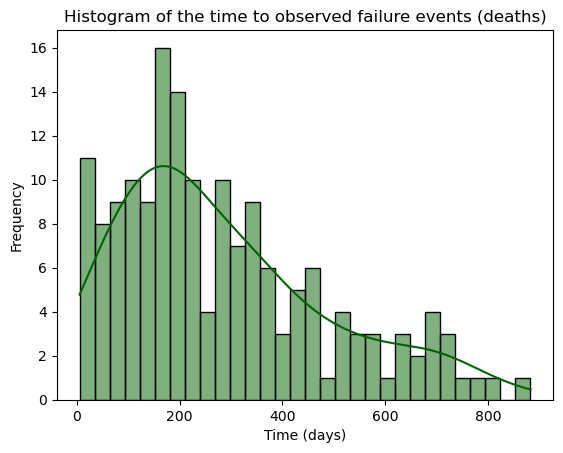

In [5]:
# My code:
# Plot a histogram of the time to observed failure events (deaths)
sns.histplot(data=lung_df[lung_df['status'] == 1], x='time', bins=30, kde=True, color='#006400')
plt.title('Histogram of the time to observed failure events (deaths)')
plt.xlabel('Time (days)')
plt.ylabel('Frequency')
plt.show()

In [6]:
# My code:
# Report the number of censored cases (who did not experience the failure event by the end of the study)
censored_cases = lung_df[lung_df['status'] == 0].shape[0]
print(f'Number of censored cases: {censored_cases}')

Number of censored cases: 63


### Kaplan-Meier Survival Plot

* Generate a Kaplan-Meier survival plot to show the probability of survival over time for the entire study population.


* Create separate Kaplan-Meier plots for the group with ```ph.ecog <= 1``` and ```ph.ecog > 1``` to explore any differences in survival rates.
    * What does the ```ph.ecog``` variable measure? 
    * What do you conclude from these results?

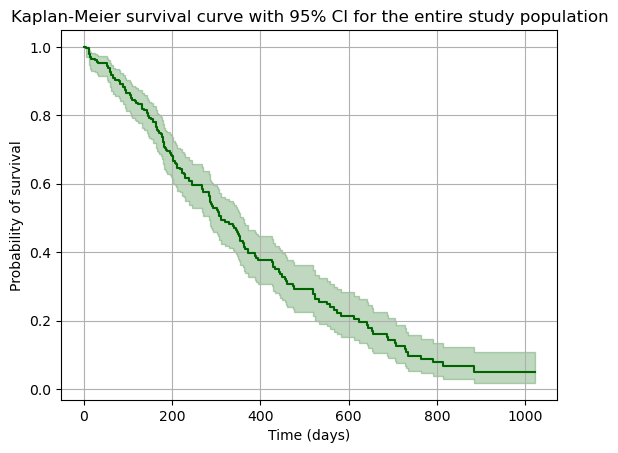

In [7]:
# My code:
# Generate a Kaplan-Meier survival plot to show the probability of survival over time for the entire study population.
KM_model = KaplanMeierFitter()    # Class for fitting the Kaplan-Meier estimate for the survival function
KM_model.fit(durations=lung_df['time'], event_observed=lung_df['status'])    # Fit the KM estimator to entire data
KM_model.plot_survival_function(color='#006400', ci_show=True, legend=False)
plt.title('Kaplan-Meier survival curve with 95% CI for the entire study population')
plt.xlabel('Time (days)')
plt.ylabel('Probability of survival')
plt.grid(True)
plt.show()

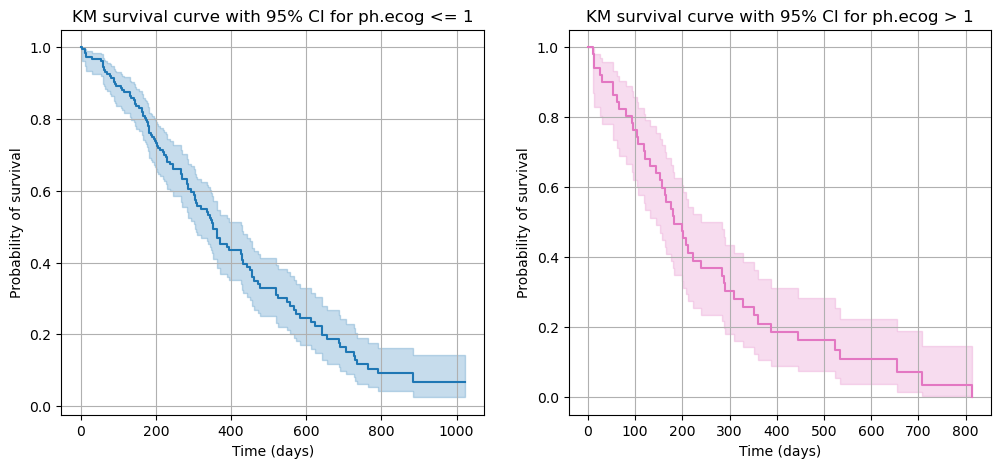

In [8]:
# My code:
# Create separate Kaplan-Meier plots for the group with ph.ecog <= 1 and ph.ecog > 1 to explore any differences in survival rates.
group_below = lung_df[lung_df['ph.ecog'] <= 1]      # Kaplan-Meier for the group with ph.ecog <= 1
KM_model_below = KaplanMeierFitter()
KM_model_below.fit(durations=group_below['time'], event_observed=group_below['status'])
group_above = lung_df[lung_df['ph.ecog'] > 1]       # Kaplan-Meier for the group with ph.ecog > 1
KM_model_above = KaplanMeierFitter()
KM_model_above.fit(durations=group_above['time'], event_observed=group_above['status'])
# Kaplan-Meier plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
KM_model_below.plot_survival_function(ax=axes[0], color='#1f77b4', ci_show=True, legend=False)
axes[0].set_title('KM survival curve with 95% CI for ph.ecog <= 1')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Probability of survival')
axes[0].grid(True)
KM_model_above.plot_survival_function(ax=axes[1], color='#e377c2', ci_show=True, legend=False)
axes[1].set_title('KM survival curve with 95% CI for ph.ecog > 1')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Probability of survival')
axes[1].grid(True)
plt.show()

What does the ph.ecog variable measure? 

Answer: 

The ph.ecog variable represents the Eastern Cooperative Oncology Group (ECOG) performance status,reflecting the patient’s capacity to tolerate treatments for serious illness, like chemotherapy [1]. Higher scores indicate worse functional status and generally worse prognosis: 0 represents asymptomatic patients, 1–3 represent symptomatic patients with progressively decreasing functional ability, 4 represents bedbound patients, and 5 indicates death.

[1] https://www.mdcalc.com/calc/3170/eastern-cooperative-oncology-group-ecog-performance-status#pearls-pitfalls

What do you conclude from these results?

Answer: 

The blue curve (low ECOG: ph.ecog <= 1) has higher values than the pink curve (high ECOG: ph.ecog > 1). This means that patients with better functional status (ph.ecog <= 1) have a higher probability of survival, while patients with worse functional status (ph.ecog > 1) have lower probability of survival. For example at 400 days, patients with lower ECOG have a probability of survival between 0.4 and 0.5, while patients with lower ECOG have a probability of survival a bit lower than 0.2. This demonstrates that better overall functional status is associated with longer probability of survival compared to poorer functional status.

## Problem 2

### Fitting a Cox Proportional Hazards Model

* Split the data so that 30% of it is used for testing and the remaining 70% is used to train the model. 
* Fit a Cox Proportional Hazards (CPH) model using the lifelines package that estimates survival time conditioned on patient covariates. 
    * Report any modeling choices you have made, such as the selection of hyperparameters and representation of discrete variables
* Report the CPH model coefficients. What does this say about the contribution of the different variables to the model?

In [9]:
# My code:
# Convert categorical variables to 'category' dtype
categorical_cols = ['inst', 'sex', 'ph.ecog']
lung_df[categorical_cols] = lung_df[categorical_cols].astype('category')
# Split the data so that 30% of it is used for testing and the remaining 70% is used to train the model
from sklearn.model_selection import train_test_split
train_lung_df, test_lung_df = train_test_split(lung_df, test_size=0.3, random_state=4)
train_lung_df = train_lung_df.reset_index(drop=True)
test_lung_df = test_lung_df.reset_index(drop=True)
# Fit a Cox Proportional Hazards (CPH) model using the lifelines package that estimates survival time conditioned on patient covariates. 
CPH_model = CoxPHFitter()    # Class fot fitting Cox’s proportional hazard model: default is the semi-parametric Cox model, using Breslow’s method
CPH_model.fit(train_lung_df, duration_col='time', event_col='status')    # Fit the CPH model to training data

<lifelines.CoxPHFitter: fitted with 159 total observations, 44 right-censored observations>

Report any modeling choices you have made, such as the selection of hyperparameters and representation of discrete variables

Answer:

The CPH model was defined with CoxPHFitter(), using the default default Breslow’s baseline hazard estimator:
$
\hat{H}_0(t) = \sum_{t_i \le t} \frac{d_i}{\sum_{j \in R_i} \exp(\hat\beta^\top X_j)}
$.

The dataframe of interest, lung_df, contains a 'time' variable representing the survival time and a 'status' variable representing the event indicator. Continuous variables include 'age', 'ph.karno', 'pat.karno', 'meal.cal', 'wt.loss', indicating naturally ordered scale. Discrete variables include 'inst', 'sex', 'ph.ecog', indicating distinct groups without a meaningful numerical distance.

Continuous variables were represented as float64, allowing the model to capture the effect of incremental changes of the variables on the probability of the event occurring, while discrete variables were represented as categorical, allowing the model to estimate separate hazard effects for each group.

Alternatively, 'inst' variable could be handled through stratification using strata=['inst'] to allow for different baseline hazards across institutions. Also, 'sex' variable could also be encoded as a binary numerical variable (0, 1). SImilarly 'ph_ecog' could also be left as a numerical variable (0, 1, 2, 3, 4), since it is ordinal and the 1-unit increase reflects a meaningful step in the ECOG performance score.

To ensure reproducibility when splitting the data into training and testing sets, 'random_state' was set to 4.

In [10]:
# My code:
# Visualize the fitted CPH model summary for each covariate
CPH_model.print_summary()

# The CPH model does not predict exact survival times, instead it predicts relative risk (hazard ratios):
# for each patient, it outputs a risk score (a linear combination of the covariates and coefficients)

# number of observations 159: number of rows in train_lung_df
# number of events observed 114: number of deaths within the training set only
# partial log-likelihood -460.92: average unpenalized partial log-likelihood measuring the model fit (the higher the better)
#                                 how well does the risk scores generated by the model align with the observed event times? (how probable is the data distribution given the model?)
#                                 -> right order and timing of events
#                                 compares each event to the risk set, all patients who were still at risk at that time

# coef: log hazard ratio (logHR)
# exp(coef): hazard ratio (HR)
#            HR near 1 → little to no effect on the event occurring, HR far from 1 → strong effect on the event occurring
#            HR < 1 → decreased risk of the event occurring, HR > 1 → increased risk of the event occurring
# se(coef): standard error of the coefficient
#           smaller se(coef) → logHR is estimated precisely, larger se(coef) → logHR is estimated with high uncertainty   
# 95% CI: range of values that likely contain the true parameter with 95% probability
# cmp to: compares the variable to the baseline
# z: Wald statistic used to test whether a coefficient is significantly different from zero.
#    z = coef / se(coef)
#    larger abs(z) → stronger evidence the covariate has a stronger effect on the event occurring
# p-value: statistical significance
#          smaller p-value → stronger evidence against the null hypothesis (the covariate has no effect on the event occurring)
#          [larger abs(z) → smaller p-value]

# concordance 0.64: C-index measuring the predictive accuracy of the model ([0,1] the higher the better)
#                   how well does the model orders patients by risk? 
#                   -> right order
#                   compares explicitly all comparable pairs of patients 

<lifelines.CoxPHFitter: fitted with 159 total observations, 44 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 159
number of events observed = 115
   partial log-likelihood = -469.00
         time fit was run = 2025-11-21 17:02:32 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
inst      -0.02      0.98      0.01           -0.05            0.00                0.95                1.00
age        0.01      1.01      0.01           -0.02            0.03                0.98                1.03
sex       -0.61      0.54      0.21           -1.02           -0.21                0.36                0.81
ph.ecog    0.67      1.96      0.23            0.23            1.12                1.26                3.07
ph.karno   0.03      1.03      0.01            0.00            0.05                1.00                1.05
pat.karno -0.02      0.98      0.01           -0.03           -0.00                0.97                1.00
meal.cal   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
wt.loss   -0.01      0.99      0.01           -0.03            0.01                0.97                1.01

           cmp to     z      p  -log2(p)
covariate                               
inst         0.00 -1.66   0.10      3.36
age          0.00  0.71   0.47      1.07
sex          0.00 -2.96 <0.005      8.36
ph.ecog      0.00  2.96 <0.005      8.35
ph.karno     0.00  2.27   0.02      5.44
pat.karno    0.00 -1.98   0.05      4.39
meal.cal     0.00  0.30   0.76      0.39
wt.loss      0.00 -1.13   0.26      1.95
---
Concordance = 0.67
Partial AIC = 954.01
log-likelihood ratio test = 31.15 on 8 df
-log2(p) of ll-ratio test = 12.89

Report the CPH model coefficients. What does this say about the contribution of the different variables to the model?

Answer:

The coefficients of the CPH model, 'coef', represent the natural logarithm of the hazard ratio. Exponentiating these coefficients gives the hazard ratio, 'exp(coef'), which indicates the effect of each covariate on the probability of the event occurring: HR near 1 indicates little to no effect on the event, HR greater than 1 indicates an increased probability of the event occurring, HR less than 1 indicates a decreased probability of the event occurring.

'ph.ecog' covariate has the largest positive effect (coef = 0.67), suggesting that higher ECOG scores are associated with an increased probability of death occurring. 'sex' covariate has the largest negative coefficient (coef = -0.61), indicating that higher values of the variable are associated with lower hazard and specifically that females (Female=2) have a lower probability of death occurring compared to males (Male=1).

'inst' (coef = -0.02), 'age' (coef = 0.01), 'ph.karno' (coef = 0.03), 'pat.karno' (coef = -0.02), and 'wt.loss' (coef = -0.01) covariates have small coefficients, associated with hazard ratios near 1, suggesting minimal effects on death.

'meal.cal' covariate have coefficients near zero (coef = 0.00), indicating no effect on death occurring.

In the summary, together with the hazard ratio and its natural logarithm, the statistical properties of these variables are repoorted, including 95% CI, indicating the range of values that likely contain the true parameter with 95% probability, and the p-value, representing statistical significance of the effect. 

Coherently, 'ph.ecog' and 'sex' are the only covariates resulting in a p-value<0.0005, indicating statistical evidence that these variables are associated with the risk of death. Other covariates have higher p-values, suggesting that their effects on the probability of death occurring are not statistically significant in this dataset. However, when interpreting these p-values, it is important to note that the number of events for certain subgroups may be small, which can reduce the reliability of the significance estimates. 

Also, it is important to note that the results are sensitive to the random sampling or ordering of the data. For example, it was observed that changing the 'random_state' to values such as 2, 10, 20, or 42 leads to higher p-values for 'ph.ecog', causing the statistical significance to vary across different data splits or resampling.

### Evaluation

* Report the test-set concordance index for the CPH model and state how to interpret the value. 
    * You can look it up, e.g., here https://scikit-survival.readthedocs.io/en/stable/user_guide/evaluating-survival-models.html.

* What is the model's partial log-likelihood score on the training and test sets?

* Compute the estimated conditional survival function $S(t|x)$ for every individual in the test set, at all event times observed in the data, using the fitted CPH model. Then compute the marginal survival function $S(t)$ based on the individual survival curves and plot it. Compare this estimate to the Kaplan-Meier (KM) survival curves for the same data:
  * How well do the CPH and KM estimates align? 
  * The CPH model is semi-parametric in that only the scaling factor that depends on $X$ has a fixed parametric form. How was the baseline hazard computed in your CPH estimate?


In [11]:
# My code:
# Report the test-set concordance index for the CPH model
test_concordance = CPH_model.score(test_lung_df, scoring_method="concordance_index")    # Score the dataframe on the fitted modeel according to the scoring method: returns the concordance-index
print(f"Test-set concordance (C-index): {test_concordance:.3f}")

Test-set concordance (C-index): 0.600


State how to interpret the value of the test-set concordance index for the CPH model:

Answer: 

The test-set concordance index measure the predictive accuracy of the CPH model on the test set. The concordance index is computed by comparing explicitly all possible pairs of patients and evaluating how well the model correctly orders patients by their predicted probability of the event to occurr. It ranges from 0.0 to 1.0, with 1.0 indicating perfect prediction and 0.5 representing prediction no better than random ordering. So a high test-set concordance index of 0.600 indicates that the model correctly orders 60% of admissible patient pairs.

In [12]:
# My code:
# What is the model's partial log-likelihood score on the training and test sets?
train_pll = CPH_model.score(train_lung_df, scoring_method="log_likelihood")   # Score the dataframe on the fitted modeel according to the scoring method: returns the average unpenalized partial log-likelihood
print(f"Training partial log-likelihood (average): {train_pll:.3f}")
test_pll = CPH_model.score(test_lung_df, scoring_method="log_likelihood")
print(f"Test partial log-likelihood (average): {test_pll:.3f}")

Training partial log-likelihood (average): -2.950
Test partial log-likelihood (average): -2.358


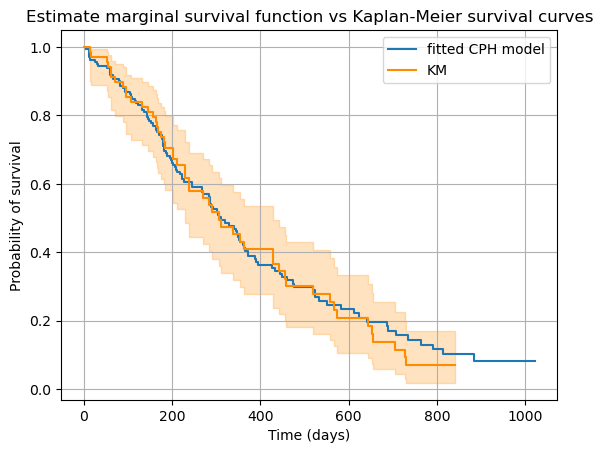

In [13]:
# My code:
# Compute the estimated conditional survival function $(t|x) for every individual in the test set, at all event times observed in the data, using the fitted CPH model.
conditional_survival_function = CPH_model.predict_survival_function(test_lung_df)
# Compute the marginal survival function S(t) based on the individual survival curves and plot it. 
marginal_survival_function = conditional_survival_function.mean(axis=1)
# Compare the estimate to the Kaplan-Meier (KM) survival curves for the same data:
KM_model = KaplanMeierFitter()
KM_model.fit(durations=test_lung_df['time'], event_observed=test_lung_df['status'], label='KM')
# Plot
plt.step(marginal_survival_function.index, marginal_survival_function.values, where='post', label='fitted CPH model') # fitted CPH model
KM_model.plot_survival_function(color='#FF8C00', ci_show=True, legend=False)  # KM
plt.xlabel('Time (days)')
plt.ylabel('Probability of survival')
plt.title('Estimate marginal survival function vs Kaplan-Meier survival curves')
plt.legend()
plt.grid(True)
plt.show()


How well do the CPH and KM estimates align? 

Answer: 

Overall, the fitted CPH model and the KM estimates align quite closely, with the CPH-predicted marginal survival function and the empirical KM estimate having similar shapes and decline rates. This means the proportional hazards assumption is not noticeably violated and that the covariates used in the CPH model capture the underlying hazard reasonably well. Starting from 400 days, and particularly beyond 600–700 days, the curves start to separate slightly, with the KM curve flattening more than the CPH curve, which continues declining at a smoother rate. This minor deviation is expected, as fewer individuals remain at risk and the KM estimator becomes less stable.

The CPH model is semi-parametric in that only the scaling factor that depends on $X$ has a fixed parametric form. How was the baseline hazard computed in your CPH estimate?

Answer: 

Since the CPH model was defined using CoxPHFitter(), the default default Breslow’s baseline hazard estimator was used. In practice, first, $β$ coefficients are estimated using the partial likelihood, then the baseline cumulative hazard is computed with Breslow’s method, finally a stepwise non-parametric baseline hazard is produced. Specifically, 

Partial likelihood: 
$
L(\beta) = \prod_{i:\,\delta_i=1} \frac{\exp(\beta^\top X_i)}{\sum_{j \in R_i} \exp(\beta^\top X_j)}
$

Breslow estimator of the baseline cumulative hazard:
$
\hat{H}_0(t) = \sum_{t_i \le t} \frac{d_i}{\sum_{j \in R_i} \exp(\hat\beta^\top X_j)}
$

Stepwise non-parametric baseline hazard:
$
\hat{h}_0(t_i) = \hat{H}_0(t_i) - \hat{H}_0(t_{i^-})
$


## Problem 3

### Effects of additional censoring

* Create an alternative data set by *changing the censoring time* of a subset of *censored* samples. Choose 50% of censored cases, selected uniformly at random, and make the censoring time 200 days longer (i.e., as if the selected patients survived for at least 200 days more and were not censored during this time). 

* Refit the Kaplan-Meier estimator from Problem 1 and compare the results of the original estimator (on the whole, unchanged population) to the refit. What do you find? Explain the pattern using the definition of the KM estimator. 

In [14]:
# My code:
# Create an alternative data set by changing the censoring time of a subset of censored samples. 
# Choose 50% of censored cases, selected uniformly at random, and make the censoring time 200 days longer.
import random
lung_df_modified = lung_df.copy()
censored_indices = lung_df[lung_df['status'] == 0].index.tolist()
indices_to_modify = random.sample(censored_indices, int(len(censored_indices) * 0.5))
lung_df_modified.loc[indices_to_modify, 'time'] += 200

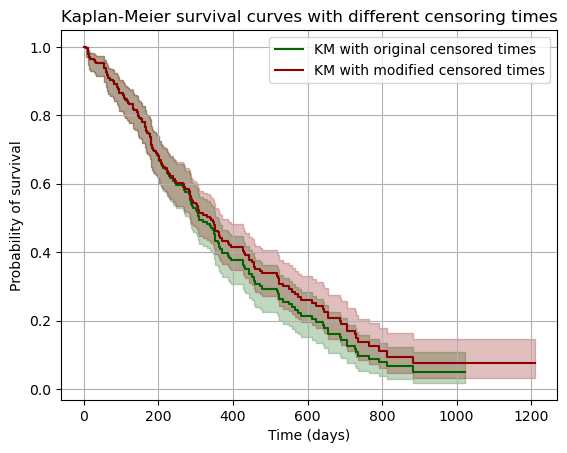

In [15]:
# My code:
# Refit the Kaplan-Meier estimator from Problem 1 and compare the results of the original estimator (on the whole, unchanged population) to the refit.
KM_model_original = KaplanMeierFitter()
KM_model_modified = KaplanMeierFitter()
KM_model_original.fit(durations=lung_df['time'], event_observed=lung_df['status'], label='KM with original censored times')
KM_model_modified.fit(durations=lung_df_modified['time'], event_observed=lung_df_modified['status'], label='KM with modified censored times')
# Plot
KM_model_original.plot_survival_function(color='#006400', ci_show=True)
KM_model_modified.plot_survival_function(color='#8B0000', ci_show=True)
plt.title('Kaplan-Meier survival curves with different censoring times')
plt.xlabel('Time (days)')
plt.ylabel('Probability of survival')
plt.legend()
plt.grid(True)
plt.show()

What do you find? Explain the pattern using the definition of the KM estimator.

Answer: 

The KM estimator is defined as:
$$
\hat{S}(t) = \prod_{t_i \le t} \left( 1 - \frac{d_i}{n_i} \right)
$$
where $t_i$ is the time of an event, $d_i$ is the number of events at $t_i$, and $n_i$ is the number of patients at risk just before $t_i$. By increasing the censoring time, some patients remain in the risk set longer, which increases $n_i$ at later times. Consequently, the fraction $\frac{d_i}{n_i}$ becomes smaller, making $1 - \frac{d_i}{n_i}$ closer to 1. Therefore, the survival probability $\hat{S}(t)$ is higher for the modified censoring times. At early times, the curves overlap closely. However, the red curve (KM curve with modified censoring times) is generally higher than the green curve (KM curve with original censoring times) at later times. 

### Limitations of the CPH model

* The Cox proportional hazards model assumes that the covariate scaling factor has a particular parametric form, $\exp(\theta^\top x)$ . This form can be ill-suited if there are strong covariate "interactions". If you have not come across the concept "covariate interaction" or "feature interaction" before, look it up, for example, [here](https://christophm.github.io/interpretable-ml-book/interaction.html). 
  * Why would feature interactions make the CPH model unsuitable? Give a general argument and a concrete hypothetical example of a pattern the CPH model would not be able to capture. 
  * By inspecting the lung cancer data set features, are there possible feature interactions that could affect lung cancer survival? 
* If you suspect that there is an important feature interaction in your survival problem, how could you handle it?
  * Suggest a small modification to the procedure from Problem 2 that works if you know which features are likely to interact. 
  * Suggest a general modeling strategy for survival analysis that could work even if the interactions are unknown.

Why would feature interactions make the CPH model unsuitable? 

Answer: 

The Cox proportional model assumes each covariate contributes independently to the hazard via $\theta_i x_i$. If there are interactions between covariates, their combined effect is not captured by a simple sum of independent contributions, so the model may misrepresent the true hazard.

By inspecting the lung cancer data set features, are there possible feature interactions that could affect lung cancer survival? 

Answer: 

Possible feature interactions might be age (age) and performance scores (ph.ecog, ph.karno, pat.karno), resulting in older patients with poor performance scores having worse survival compared to younger patients with similar scores. Also, weight loss (wt.loss) and meal calories (meal.cal) might interact, resulting in patients who consume few calories and also experience high weight loss having a higher risk than expected from each factor individually.  

If you suspect that there is an important feature interaction in your survival problem, how could you handle it?

Answer: 

If likely interacting features are known, they can be explicitely included in the Cox model, by creating a new feature as their product:

$$
h(t \mid x) = h_0(t) \, \exp\Big(\sum_i \theta_i x_i + \sum_{j,k} \theta_{jk} x_j x_k \Big)
$$

where the second sum runs over all pairs of covariates $x_j$ and $x_k$ that are interacting. However, if interactions are unknown, more complex survival models can be used to automatically capture potential interactions. For example data-driven methods like random survival forests (RSF) or DeepSurv, a neural network-based survival model, can be used [2][3].

[2] Hemant Ishwaran, Udaya B. Kogalur, Eugene H. Blackstone, Michael S. Lauer "Random survival forests," The Annals of Applied Statistics, Ann. Appl. Stat. 2(3), 841-860, (September 2008). https://doi.org/10.1214/08-AOAS169

[3] Katzman, J.L., Shaham, U., Cloninger, A. et al. DeepSurv: personalized treatment recommender system using a Cox proportional hazards deep neural network. BMC Med Res Methodol 18, 24 (2018). https://doi.org/10.1186/s12874-018-0482-1

#### Disclosure of the use of AI tools

In VS Code, I first read and understood the assignment instructions. I then wrote a comment in a Python cell with a specific task description and reviewed the code suggested by Copilot. After an initial analysis, I consulted the Python documentation for the classes, methods, and functions used. After understanding how they work, I critically evaluated Copilot's suggestions, added comments, and made adjustments. Whenever something was unclear, I used ChatGPT as a guide to deeper understand the reasoning behind certain choices and functions.